In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
rfm_df = pd.read_csv("../data/processed/customer_rfm_features.csv")

rfm_df["first_purchase"] = pd.to_datetime(rfm_df["first_purchase"])
rfm_df["last_purchase"] = pd.to_datetime(rfm_df["last_purchase"])

print("RFM data shape:", rfm_df.shape)

rfm_df.head()

RFM data shape: (4338, 20)


,customer_id,recency,frequency,monetary,monetary_capped,total_quantity,unique_products,avg_order_value,first_purchase,last_purchase,customer_lifetime_days,purchase_frequency_per_month,avg_quantity_per_order,monetary_per_order,product_diversity_ratio,r_score,f_score,m_score,rfm_score,rfm_segment
0,12346,326,1,77183.60,77183.600,74215,1,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,0,30.000000,74215.000000,77183.600000,0.000560,1,1,5,7,Medium Value
1,12347,2,7,4310.00,4166.600,2458,103,23.681319,2010-12-07 14:57:00,2011-12-07 15:52:00,365,0.573770,351.142857,615.714286,0.057639,5,5,5,15,Top Value
2,12348,75,4,1797.24,1770.240,2341,22,57.975484,2010-12-16 19:09:00,2011-09-25 13:13:00,282,0.424028,585.250000,449.310000,0.012311,2,4,4,10,High Value
3,12349,19,1,1757.55,1587.486,631,73,24.076027,2011-11-21 09:51:00,2011-11-21 09:51:00,0,30.000000,631.000000,1757.550000,0.040851,4,1,4,9,Medium Value
4,12350,310,1,334.40,332.032,197,17,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,30.000000,197.000000,334.400000,0.009513,1,1,2,4,Low Value


In [4]:
clv_df = rfm_df.copy()

clv_df["clv"] = clv_df["monetary"]

clv_df["log_clv"] = np.log1p(clv_df["clv"])

clv_df[["customer_id", "clv", "log_clv"]].head()

,customer_id,clv,log_clv
0,12346,77183.60,11.253955
1,12347,4310.00,8.368925
2,12348,1797.24,7.494564
3,12349,1757.55,7.472245
4,12350,334.40,5.815324


In [5]:
clv_df["clv_category"] = pd.qcut(
    clv_df["clv"].rank(method="first"),
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Very High Value"
    ]
)

clv_df["clv_category"].value_counts()

clv_category
Low Value          1085
Very High Value    1085
Medium Value       1084
High Value         1084
Name: count, dtype: int64

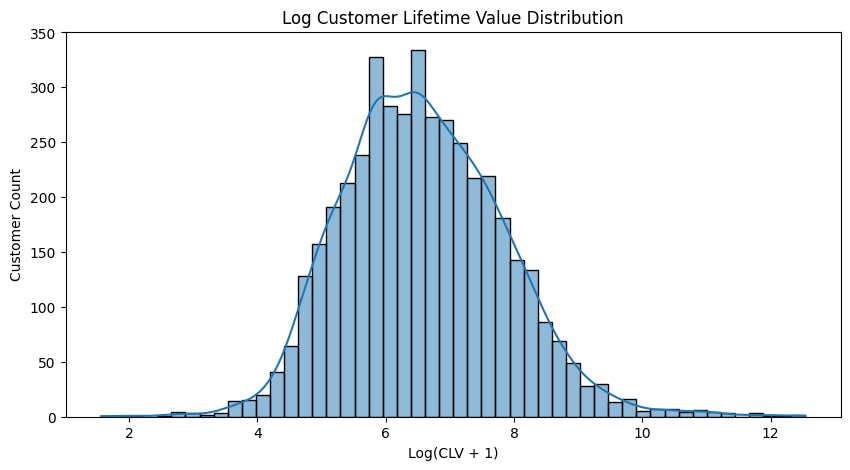

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    clv_df["log_clv"],
    bins=50,
    kde=True
)

plt.title("Log Customer Lifetime Value Distribution")
plt.xlabel("Log(CLV + 1)")
plt.ylabel("Customer Count")

plt.show()

In [7]:
feature_cols = [
    "recency",
    "frequency",
    "total_quantity",
    "unique_products",
    "avg_order_value",
    "customer_lifetime_days",
    "purchase_frequency_per_month",
    "avg_quantity_per_order",
    "product_diversity_ratio",
    "r_score",
    "f_score",
    "m_score",
    "rfm_score"
]

X = clv_df[feature_cols].copy()
y = clv_df["log_clv"].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (4338, 13)
y shape: (4338,)


,recency,frequency,total_quantity,unique_products,avg_order_value,customer_lifetime_days,purchase_frequency_per_month,avg_quantity_per_order,product_diversity_ratio,r_score,f_score,m_score,rfm_score
0,326,1,74215,1,77183.600000,0,30.000000,74215.000000,0.000560,1,1,5,7
1,2,7,2458,103,23.681319,365,0.573770,351.142857,0.057639,5,5,5,15
2,75,4,2341,22,57.975484,282,0.424028,585.250000,0.012311,2,4,4,10
3,19,1,631,73,24.076027,0,30.000000,631.000000,0.040851,4,1,4,9
4,310,1,197,17,19.670588,0,30.000000,197.000000,0.009513,1,1,2,4


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (3470, 13)
X_test: (868, 13)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_clv = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_clv.fit(X_train, y_train)

rf_preds = rf_clv.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("Random Forest CLV Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest CLV Results
MAE : 0.12600666267329025
RMSE: 0.17975907120823886
R²  : 0.9798623032891796


In [10]:
from xgboost import XGBRegressor

xgb_clv = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_clv.fit(
    X_train,
    y_train
)

xgb_preds = xgb_clv.predict(
    X_test
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_preds
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_preds
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("XGBoost CLV Results")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost CLV Results
MAE : 0.10409396126166294
RMSE: 0.15427861893439226
R²  : 0.9851666361466299


In [11]:
clv_model_comparison = pd.DataFrame({
    "model": [
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        rf_r2,
        xgb_r2
    ]
})

clv_model_comparison = clv_model_comparison.sort_values(
    by="R2",
    ascending=False
)

clv_model_comparison

,model,MAE,RMSE,R2
1,XGBoost,0.104094,0.154279,0.985167
0,Random Forest,0.126007,0.179759,0.979862


In [12]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_clv.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
11,m_score,0.870474
2,total_quantity,0.075598
12,rfm_score,0.020607
1,frequency,0.008103
8,product_diversity_ratio,0.006128
4,avg_order_value,0.005555
3,unique_products,0.004709
7,avg_quantity_per_order,0.003018
5,customer_lifetime_days,0.001396
6,purchase_frequency_per_month,0.001286


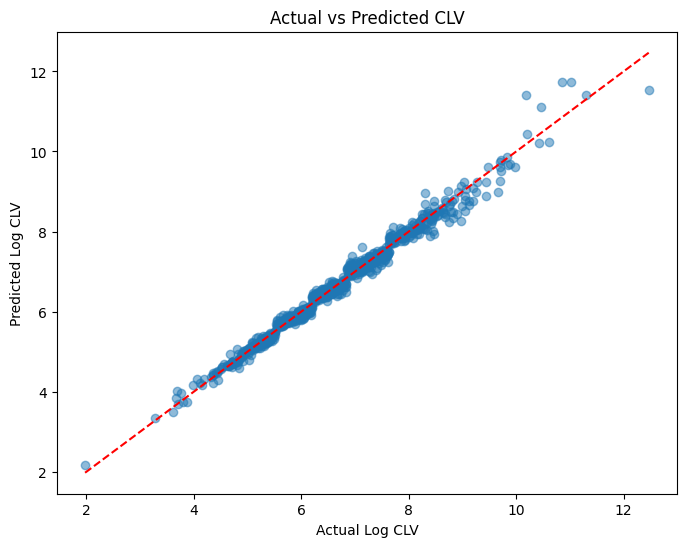

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_preds,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Log CLV")
plt.ylabel("Predicted Log CLV")
plt.title("Actual vs Predicted CLV")

plt.show()

## A NEW CLV

In [14]:
from sklearn.preprocessing import LabelEncoder

clv_label_encoder = LabelEncoder()

y_clv_class = clv_label_encoder.fit_transform(
    clv_df["clv_category"]
)

print("Classes:")
for i, label in enumerate(clv_label_encoder.classes_):
    print(i, "->", label)

print("\nTarget shape:", y_clv_class.shape)

Classes:
0 -> High Value
1 -> Low Value
2 -> Medium Value
3 -> Very High Value

Target shape: (4338,)


In [15]:
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clv_class,
    test_size=0.20,
    random_state=42,
    stratify=y_clv_class
)

print("Train:", X_train_clf.shape)
print("Test :", X_test_clf.shape)

Train: (3470, 13)
Test : (868, 13)


In [16]:
from xgboost import XGBClassifier

clv_classifier = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="multi:softprob",
    eval_metric="mlogloss"
)

clv_classifier.fit(
    X_train_clf,
    y_train_clf
)

clf_preds = clv_classifier.predict(
    X_test_clf
)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test_clf,
    clf_preds
)

print("CLV Classification Accuracy:")
print(round(accuracy, 4))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_clf,
        clf_preds,
        target_names=clv_label_encoder.classes_
    )
)

CLV Classification Accuracy:
0.9147

Classification Report:

                 precision    recall  f1-score   support

     High Value       0.86      0.91      0.89       217
      Low Value       0.99      0.90      0.94       217
   Medium Value       0.85      0.93      0.89       217
Very High Value       0.98      0.91      0.94       217

       accuracy                           0.91       868
      macro avg       0.92      0.91      0.92       868
   weighted avg       0.92      0.91      0.92       868



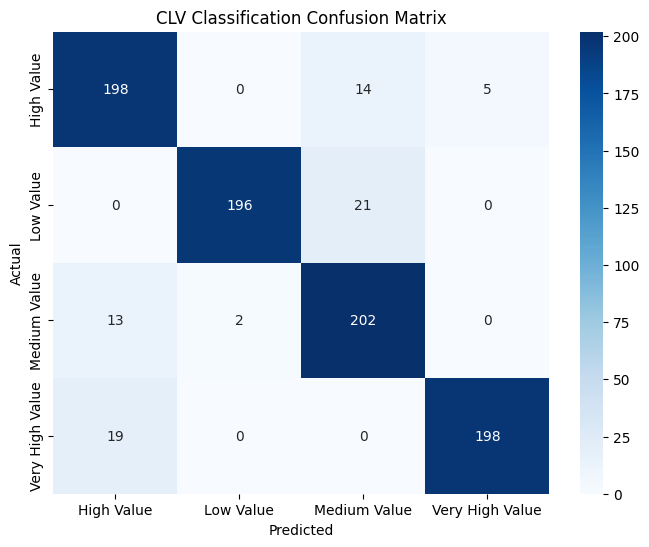

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_clf,
    clf_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clv_label_encoder.classes_,
    yticklabels=clv_label_encoder.classes_
)

plt.title("CLV Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
clv_feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": clv_classifier.feature_importances_
})

clv_feature_importance = (
    clv_feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
)

clv_feature_importance.head(15)

,feature,importance
11,m_score,0.689864
2,total_quantity,0.081957
12,rfm_score,0.050178
4,avg_order_value,0.027855
8,product_diversity_ratio,0.026680
1,frequency,0.026029
3,unique_products,0.025099
10,f_score,0.013582
5,customer_lifetime_days,0.013425
7,avg_quantity_per_order,0.013315


In [21]:
import joblib

joblib.dump(
    clv_classifier,
    "../models/xgboost_clv_classifier.pkl"
)

print("CLV classifier saved.")

CLV classifier saved.


In [25]:
# Generate predictions

clv_predictions = clv_classifier.predict(X_test)

clv_results = pd.DataFrame({
    "actual_log_clv": y_test,
    "predicted_log_clv": clv_predictions
})

clv_results["actual_clv"] = np.expm1(
    clv_results["actual_log_clv"]
)

clv_results["predicted_clv"] = np.expm1(
    clv_results["predicted_log_clv"]
)

clv_results.to_csv(
    "../data/processed/clv_predictions.csv",
    index=False
)

print("CLV predictions saved.")

CLV predictions saved.


In [26]:
clv_feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": clv_classifier.feature_importances_
})

clv_feature_importance = (
    clv_feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

clv_feature_importance.to_csv(
    "../data/processed/clv_feature_importance.csv",
    index=False
)

clv_feature_importance.head()

,feature,importance
11,m_score,0.689864
2,total_quantity,0.081957
12,rfm_score,0.050178
4,avg_order_value,0.027855
8,product_diversity_ratio,0.026680


In [27]:
clv_model_comparison = pd.DataFrame({
    "model": [
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        rf_r2,
        xgb_r2
    ]
})

clv_model_comparison.to_csv(
    "../data/processed/clv_model_comparison.csv",
    index=False
)

clv_model_comparison

,model,MAE,RMSE,R2
0,Random Forest,0.126007,0.179759,0.979862
1,XGBoost,0.104094,0.154279,0.985167


In [28]:
classification_predictions = clv_classifier.predict(
    X_test
)

clv_classification_results = pd.DataFrame({
    "actual_category": y_test,
    "predicted_category": classification_predictions
})

clv_classification_results.to_csv(
    "../data/processed/clv_classification_results.csv",
    index=False
)

print(
    "CLV classification results saved."
)

CLV classification results saved.
